In [ ]:
!pip install kagglehub

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# **1. Data Profiling**

In [ ]:
path = kagglehub.dataset_download(
    "hassanelfattmi/why-do-customers-leave-can-you-spot-the-churners"
)

print("Path dataset:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'why-do-customers-leave-can-you-spot-the-churners' dataset.
Path dataset: /kaggle/input/why-do-customers-leave-can-you-spot-the-churners
Files: ['Status_Analysis.csv', 'Online_Services.csv', 'a_IBM Telco Customers Churn Datasets.xlsx', 'Customer_Info.csv', 'TELCO ER Diagram.png', 'Service_Options.csv', 'Location_Data.csv', 'Payment_Info.csv']


In [ ]:
df_payment = pd.read_csv(os.path.join(path, "Payment_Info.csv"))
df_onserv = pd.read_csv(os.path.join(path, "Online_Services.csv"))
df_customer = pd.read_csv(os.path.join(path, "Customer_Info.csv"))
df_location = pd.read_csv(os.path.join(path, "Location_Data.csv"))
df_status = pd.read_csv(os.path.join(path, "Status_Analysis.csv"))
df_service_options = pd.read_csv(os.path.join(path, "Service_Options.csv"))

## **1.2 Dataset Overview**

### **1.2.1 Payment**

In [ ]:
df_payment.head()

,customer_id,contract,paperless_billing,payment_method,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
0,0002-ORFBO,One Year,Yes,Mailed check,65.6,42.39,593.30,0.00,0,381.51,974.81
1,0003-MKNFE,Month-to-Month,No,Mailed check,59.9,10.69,542.40,38.33,10,96.21,610.28
2,0004-TLHLJ,Month-to-Month,Yes,Electronic check,73.9,33.65,280.85,0.00,0,134.60,415.45
3,0011-IGKFF,Month-to-Month,Yes,Electronic check,98.0,27.82,1237.85,0.00,0,361.66,1599.51
4,0013-EXCHZ,Month-to-Month,Yes,Mailed check,83.9,7.38,267.40,0.00,0,22.14,289.54


In [ ]:
df_payment["contract"].unique()

array(['One Year', 'Month-to-Month', 'Two Year'], dtype=object)

In [ ]:
df_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   contract                           7043 non-null   object 
 2   paperless_billing                  7043 non-null   object 
 3   payment_method                     7043 non-null   object 
 4   monthly_ charges                   7043 non-null   float64
 5   avg_monthly_long_distance_charges  7043 non-null   float64
 6   total_charges                      7043 non-null   float64
 7   total_refunds                      7043 non-null   float64
 8   total_extra_data_charges           7043 non-null   int64  
 9   total_long_distance_charges        7043 non-null   float64
 10  total_revenue                      7043 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 605.4+ 

In [ ]:
print("DATA PAYMENT")
print("\nJumlah rows:", len(df_payment))
print("Jumlah pelanggan unik :", df_payment['customer_id'].nunique())
print("Jumlah baris duplikat  :", df_payment.duplicated().sum())
print("Missing value sales per kolom:")
print(df_payment.isna().sum())

DATA PAYMENT

Jumlah rows: 7043
Jumlah pelanggan unik : 7043
Jumlah baris duplikat  : 0
Missing value sales per kolom:
customer_id                          0
contract                             0
paperless_billing                    0
payment_method                       0
monthly_ charges                     0
avg_monthly_long_distance_charges    0
total_charges                        0
total_refunds                        0
total_extra_data_charges             0
total_long_distance_charges          0
total_revenue                        0
dtype: int64


In [ ]:
df_payment.select_dtypes(include="object").describe().T

,count,unique,top,freq
customer_id,7043,7043,9995-HOTOH,1
contract,7043,3,Month-to-Month,3610
paperless_billing,7043,2,Yes,4171
payment_method,7043,4,Electronic check,2365


In [ ]:
df_payment.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_ charges,7043.0,64.761692,30.090047,18.25,35.500,70.35,89.850,118.75
avg_monthly_long_distance_charges,7043.0,22.958954,15.448113,0.00,9.210,22.89,36.395,49.99
total_charges,7043.0,2280.381264,2266.220462,18.80,400.150,1394.55,3786.600,8684.80
total_refunds,7043.0,1.962182,7.902614,0.00,0.000,0.00,0.000,49.79
total_extra_data_charges,7043.0,6.860713,25.104978,0.00,0.000,0.00,0.000,150.00
total_long_distance_charges,7043.0,749.099262,846.660055,0.00,70.545,401.44,1191.100,3564.72
total_revenue,7043.0,3034.379056,2865.204542,21.36,605.610,2108.64,4801.145,11979.34


### **1.2.2 Customers**

In [ ]:
df_customer.head()

,customer_id,gender,age,under_30,senior_citizen,partner,dependents,number_of_dependents,married
0,0002-ORFBO,Female,37,No,No,Yes,No,0,Yes
1,0003-MKNFE,Male,46,No,No,No,No,0,No
2,0004-TLHLJ,Male,50,No,No,No,No,0,No
3,0011-IGKFF,Male,78,No,Yes,Yes,No,0,Yes
4,0013-EXCHZ,Female,75,No,Yes,Yes,No,0,Yes


In [ ]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           7043 non-null   object
 1   gender                7043 non-null   object
 2   age                   7043 non-null   int64 
 3   under_30              7043 non-null   object
 4   senior_citizen        7043 non-null   object
 5   partner               7043 non-null   object
 6   dependents            7043 non-null   object
 7   number_of_dependents  7043 non-null   int64 
 8   married               7043 non-null   object
dtypes: int64(2), object(7)
memory usage: 495.3+ KB


In [ ]:
print("DATA CUSTOMERS")
print("\nJumlah rows:", len(df_customer))
print("Jumlah pelanggan unik :", df_customer['customer_id'].nunique())
print("Jumlah baris duplikat  :", df_customer.duplicated().sum())
print("Missing value sales per kolom:")
print(df_customer.isna().sum())

DATA CUSTOMERS

Jumlah rows: 7043
Jumlah pelanggan unik : 7043
Jumlah baris duplikat  : 0
Missing value sales per kolom:
customer_id             0
gender                  0
age                     0
under_30                0
senior_citizen          0
partner                 0
dependents              0
number_of_dependents    0
married                 0
dtype: int64


In [ ]:
df_customer.select_dtypes(include="object").describe().T

,count,unique,top,freq
customer_id,7043,7043,9995-HOTOH,1
gender,7043,2,Male,3555
under_30,7043,2,No,5642
senior_citizen,7043,2,No,5901
partner,7043,2,No,3641
dependents,7043,2,No,5416
married,7043,2,No,3641


In [ ]:
df_customer.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
age,7043.0,46.509726,16.750352,19.0,32.0,46.0,60.0,80.0
number_of_dependents,7043.0,0.468692,0.962802,0.0,0.0,0.0,0.0,9.0


### **1.2.3 Online Services**

In [ ]:
df_onserv.head()

,customer_id,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type
0,0002-ORFBO,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Cable
1,0003-MKNFE,Yes,Yes,No,No,No,No,No,Yes,Yes,Cable
2,0004-TLHLJ,Yes,Yes,No,No,Yes,No,No,No,No,Fiber Optic
3,0011-IGKFF,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Fiber Optic
4,0013-EXCHZ,Yes,Yes,No,No,No,Yes,Yes,No,No,Fiber Optic


In [ ]:
df_onserv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           7043 non-null   object
 1   phone_service         7043 non-null   object
 2   internet_service      7043 non-null   object
 3   online_security       7043 non-null   object
 4   online_backup         7043 non-null   object
 5   device_protection     7043 non-null   object
 6   premium_tech_support  7043 non-null   object
 7   streaming_tv          7043 non-null   object
 8   streaming_movies      7043 non-null   object
 9   streaming_music       7043 non-null   object
 10  internet_type         5517 non-null   object
dtypes: object(11)
memory usage: 605.4+ KB


In [ ]:
print("DATA ONLINE SERVICES")
print("\nJumlah rows:", len(df_onserv))
print("Jumlah pelanggan unik :", df_onserv['customer_id'].nunique())
print("Jumlah baris duplikat  :", df_onserv.duplicated().sum())
print("Missing value sales per kolom:")
print(df_onserv.isna().sum())

DATA ONLINE SERVICES

Jumlah rows: 7043
Jumlah pelanggan unik : 7043
Jumlah baris duplikat  : 0
Missing value sales per kolom:
customer_id                0
phone_service              0
internet_service           0
online_security            0
online_backup              0
device_protection          0
premium_tech_support       0
streaming_tv               0
streaming_movies           0
streaming_music            0
internet_type           1526
dtype: int64


In [ ]:
df_onserv.head()

,customer_id,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type
0,0002-ORFBO,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Cable
1,0003-MKNFE,Yes,Yes,No,No,No,No,No,Yes,Yes,Cable
2,0004-TLHLJ,Yes,Yes,No,No,Yes,No,No,No,No,Fiber Optic
3,0011-IGKFF,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Fiber Optic
4,0013-EXCHZ,Yes,Yes,No,No,No,Yes,Yes,No,No,Fiber Optic


In [ ]:
df_onserv[df_onserv['internet_type'].isnull()].head(10)

,customer_id,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type
20,0023-UYUPN,Yes,No,No,No,No,No,No,No,No,NaN
23,0030-FNXPP,Yes,No,No,No,No,No,No,No,No,NaN
24,0031-PVLZI,Yes,No,No,No,No,No,No,No,No,NaN
27,0040-HALCW,Yes,No,No,No,No,No,No,No,No,NaN
28,0042-JVWOJ,Yes,No,No,No,No,No,No,No,No,NaN
29,0042-RLHYP,Yes,No,No,No,No,No,No,No,No,NaN
31,0048-PIHNL,Yes,No,No,No,No,No,No,No,No,NaN
33,0052-YNYOT,Yes,No,No,No,No,No,No,No,No,NaN
35,0057-QBUQH,Yes,No,No,No,No,No,No,No,No,NaN
38,0064-SUDOG,Yes,No,No,No,No,No,No,No,No,NaN


Analisa:
- Terdapat 1.526 nilai kosong pada kolom internet_type. Berdasarkan pengecekan pada kolom internet_type untuk df_onserv, nilai NaN menunjukkan pelanggan yang tidak menggunakan layanan internet. Oleh karena itu, data tidak dihapus dan nilai kosong dikategorikan sebagai No Internet Service.

In [ ]:
df_onserv.select_dtypes(include="object").describe().T

,count,unique,top,freq
customer_id,7043,7043,9995-HOTOH,1
phone_service,7043,2,Yes,6361
internet_service,7043,2,Yes,5517
online_security,7043,2,No,5024
online_backup,7043,2,No,4614
device_protection,7043,2,No,4621
premium_tech_support,7043,2,No,4999
streaming_tv,7043,2,No,4336
streaming_movies,7043,2,No,4311
streaming_music,7043,2,No,4555


### **1.2.4 Location**

In [ ]:
df_location.head()

,customer_id,country,state,city,zip_code,total_population,latitude,longitude
0,0002-ORFBO,United States,California,Frazier Park,93225,4498,34.827662,-118.999073
1,0003-MKNFE,United States,California,Glendale,91206,31297,34.162515,-118.203869
2,0004-TLHLJ,United States,California,Costa Mesa,92627,62069,33.645672,-117.922613
3,0011-IGKFF,United States,California,Martinez,94553,46677,38.014457,-122.115432
4,0013-EXCHZ,United States,California,Camarillo,93010,42853,34.227846,-119.079903


In [ ]:
df_location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       7043 non-null   object 
 1   country           7043 non-null   object 
 2   state             7043 non-null   object 
 3   city              7043 non-null   object 
 4   zip_code          7043 non-null   int64  
 5   total_population  7043 non-null   int64  
 6   latitude          7043 non-null   float64
 7   longitude         7043 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 440.3+ KB


In [ ]:
print("DATA LOCATION")
print("\nJumlah rows:", len(df_location))
print("Jumlah pelanggan unik :", df_location['customer_id'].nunique())
print("Jumlah baris duplikat  :", df_location.duplicated().sum())
print("Missing value sales per kolom:")
print(df_location.isna().sum())

DATA LOCATION

Jumlah rows: 7043
Jumlah pelanggan unik : 7043
Jumlah baris duplikat  : 0
Missing value sales per kolom:
customer_id         0
country             0
state               0
city                0
zip_code            0
total_population    0
latitude            0
longitude           0
dtype: int64


In [ ]:
df_location.select_dtypes(include="object").describe().T

,count,unique,top,freq
customer_id,7043,7043,9995-HOTOH,1
country,7043,1,United States,7043
state,7043,1,California,7043
city,7043,1106,Los Angeles,293


In [ ]:
df_location['total_population'].describe().T

,total_population
count,7043.000000
mean,22139.814568
std,21152.174407
min,11.000000
25%,2344.000000
50%,17554.000000
75%,36125.000000
max,105285.000000


### **1.2.5 Status Analysis**

In [ ]:
df_status.head()

,customer_id,satisfaction_score,cltv,customer_status,churn_score,churn_label,churn_value,churn_category,churn_reason
0,0002-ORFBO,3,2205,Stayed,65,No,0,Not Applicable,NaN
1,0003-MKNFE,5,5414,Stayed,66,No,0,Not Applicable,NaN
2,0004-TLHLJ,1,4479,Churned,71,Yes,1,Competitor,Competitor had better devices
3,0011-IGKFF,1,3714,Churned,91,Yes,1,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,1,3464,Churned,68,Yes,1,Dissatisfaction,Network reliability


In [ ]:
df_status.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         7043 non-null   object
 1   satisfaction_score  7043 non-null   int64 
 2   cltv                7043 non-null   int64 
 3   customer_status     7043 non-null   object
 4   churn_score         7043 non-null   int64 
 5   churn_label         7043 non-null   object
 6   churn_value         7043 non-null   int64 
 7   churn_category      7043 non-null   object
 8   churn_reason        1869 non-null   object
dtypes: int64(4), object(5)
memory usage: 495.3+ KB


In [ ]:
print("DATA STATUS ANALYSIS")
print("\nJumlah rows:", len(df_status))
print("Jumlah pelanggan unik :", df_status['customer_id'].nunique())
print("Jumlah baris duplikat  :", df_status.duplicated().sum())
print("Missing value sales per kolom:")
print(df_status.isna().sum())

DATA STATUS ANALYSIS

Jumlah rows: 7043
Jumlah pelanggan unik : 7043
Jumlah baris duplikat  : 0
Missing value sales per kolom:
customer_id              0
satisfaction_score       0
cltv                     0
customer_status          0
churn_score              0
churn_label              0
churn_value              0
churn_category           0
churn_reason          5174
dtype: int64


Analisa:
- Jumlah NaN pada kolom churn_reason sebanyak 5.174 data. Nilai kosong tersebut menunjukkan pelanggan yang belum mengalami churn, sehingga tidak memiliki alasan penghentian layanan. Oleh karena itu, data tidak dihapus.

In [ ]:
df_status.select_dtypes(include="object").describe().T

,count,unique,top,freq
customer_id,7043,7043,9995-HOTOH,1
customer_status,7043,3,Stayed,4720
churn_label,7043,2,No,5174
churn_category,7043,6,Not Applicable,5174
churn_reason,1869,20,Competitor had better devices,313


In [ ]:
df_status.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_score,7043.0,3.244924,1.201657,1.0,3.0,3.0,4.0,5.0
cltv,7043.0,4400.295755,1183.057152,2003.0,3469.0,4527.0,5380.5,6500.0
churn_score,7043.0,58.505040,21.170031,5.0,40.0,61.0,75.5,96.0
churn_value,7043.0,0.265370,0.441561,0.0,0.0,0.0,1.0,1.0


### **1.2.6 Service Options**

In [ ]:
df_service_options.head()

,customer_id,tenure,internet_service,phone_service,multiple_lines,avg_monthly_gb_download,unlimited_data,offer,referred_a_friend,number_of_referrals
0,0002-ORFBO,9,Yes,Yes,No,16,Yes,NaN,Yes,2
1,0003-MKNFE,9,Yes,Yes,Yes,10,No,NaN,No,0
2,0004-TLHLJ,4,Yes,Yes,No,30,Yes,Offer E,No,0
3,0011-IGKFF,13,Yes,Yes,No,4,Yes,Offer D,Yes,1
4,0013-EXCHZ,3,Yes,Yes,No,11,Yes,NaN,Yes,3


In [ ]:
df_service_options.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   customer_id              7043 non-null   object
 1   tenure                   7043 non-null   int64 
 2   internet_service         7043 non-null   object
 3   phone_service            7043 non-null   object
 4   multiple_lines           7043 non-null   object
 5   avg_monthly_gb_download  7043 non-null   int64 
 6   unlimited_data           7043 non-null   object
 7   offer                    3166 non-null   object
 8   referred_a_friend        7043 non-null   object
 9   number_of_referrals      7043 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


In [ ]:
print("DATA Service Options")
print("\nJumlah rows:", len(df_Service_Options))
print("Jumlah pelanggan unik :", df_Service_Options['customer_id'].nunique())
print("Jumlah baris duplikat  :", df_Service_Options.duplicated().sum())
print("Missing value sales per kolom:")
print(df_Service_Options.isna().sum())

DATA Service Options

Jumlah rows: 7043
Jumlah pelanggan unik : 7043
Jumlah baris duplikat  : 0
Missing value sales per kolom:
customer_id                   0
tenure                        0
internet_service              0
phone_service                 0
multiple_lines                0
avg_monthly_gb_download       0
unlimited_data                0
offer                      3877
referred_a_friend             0
number_of_referrals           0
dtype: int64


In [ ]:
df_service_options["offer"] = df_service_options["offer"].fillna("No Offer")

In [ ]:
df_service_options.select_dtypes(include="object").describe().T

,count,unique,top,freq
customer_id,7043,7043,9995-HOTOH,1
internet_service,7043,2,Yes,5517
phone_service,7043,2,Yes,6361
multiple_lines,7043,2,No,4072
unlimited_data,7043,2,Yes,4745
offer,7043,6,No Offer,3877
referred_a_friend,7043,2,No,3821


# **2. Data Manipulation**

## **2.1 Join/Merge Tabel**

In [ ]:
df = df_customer.copy()

# Merge Payment Information
df = df.merge(
    df_payment,
    on="customer_id",
    how="left"
)

# Merge Online Services
df = df.merge(
    df_onserv,
    on="customer_id",
    how="left"
)

# Merge Location
df = df.merge(
    df_location,
    on="customer_id",
    how="left"
)

# Merge Status & Churn
df = df.merge(
    df_status,
    on="customer_id",
    how="left"
)

# Merge Service Options
df = df.merge(
    df_service_options,
    on="customer_id",
    how="left"
)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 53)
Columns: ['customer_id', 'gender', 'age', 'under_30', 'senior_citizen', 'partner', 'dependents', 'number_of_dependents', 'married', 'contract', 'paperless_billing', 'payment_method', 'monthly_ charges', 'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'phone_service_x', 'internet_service_x', 'online_security', 'online_backup', 'device_protection', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'internet_type', 'country', 'state', 'city', 'zip_code', 'total_population', 'latitude', 'longitude', 'satisfaction_score', 'cltv', 'customer_status', 'churn_score', 'churn_label', 'churn_value', 'churn_category', 'churn_reason', 'tenure', 'internet_service_y', 'phone_service_y', 'multiple_lines', 'avg_monthly_gb_download', 'unlimited_data', 'offer', 'referred_a_friend', 'number_of_referrals']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   partner                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   married                            7043 non-null   object 
 9   contract                           7043 non-null   object 
 10  paperless_billing                  7043 non-null   object 
 11  payment_method                     7043 non-null   objec

In [ ]:
df.isna().sum()

,0
customer_id,0
gender,0
age,0
under_30,0
senior_citizen,0
partner,0
dependents,0
number_of_dependents,0
married,0
contract,0


In [ ]:
pd.crosstab(
          df['internet_service'],
          df['internet_type'].isna()
)

internet_type,False,True
internet_service,,
No,0,1526
Yes,5517,0


In [ ]:
pd.crosstab(
    df['churn_label'],
    df['churn_reason'].isna()
)

churn_reason,False,True
churn_label,,
No,0,5174
Yes,1869,0


In [265]:
# Handling Missing Value Offer
df_service_options["offer"] = df_service_options["offer"].fillna("No Offer")

# **3. Feature Engineering**

## **3.1 Age Group**

In [ ]:
def age_group(age):
    if age <= 18:
        return "Under 18"
    elif age <= 29:
        return "18-29"
    elif age <= 39:
        return "30-39"
    elif age <= 49:
        return "40-49"
    elif age <= 59:
        return "50-59"
    else:
        return "60+"

df["Age Group"] = df["age"].apply(age_group)

In [ ]:
age_group = (
    df.groupby("Age Group")["customer_id"]
      .count()
      .reset_index()
      .sort_values(by="customer_id", ascending=False)
)

age_group

,Age Group,customer_id
4,60+,1782
0,18-29,1401
2,40-49,1342
1,30-39,1266
3,50-59,1252


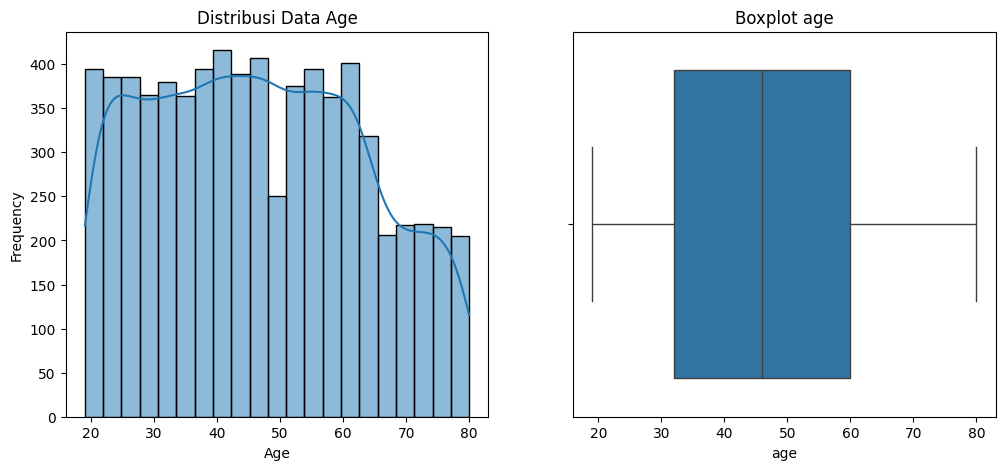

Analisis age
count    7043.000000
mean       46.509726
std        16.750352
min        19.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        80.000000
Name: age, dtype: float64
Lower Bound: -10.00
Upper Bound: 102.00
Jumlah Outlier: 0


In [ ]:
# Mengecek Distribusi Age
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df['age'], kde=True)
plt.title('Distribusi Data Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df['age'])
plt.title('Boxplot age')
plt.xlabel('age')

plt.show()

# Menghitung batas outlier menggunakan metode IQR
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengidentifikasi outlier
outliers = df[
    (df['age'] < lower_bound) |
    (df['age'] > upper_bound)
]

print('Analisis age')
print(df['age'].describe())
print(f'Lower Bound: {lower_bound:.2f}')
print(f'Upper Bound: {upper_bound:.2f}')
print(f'Jumlah Outlier: {len(outliers)}')

## **3.1 CLTV Tier**

In [ ]:
df['cltv'].head()

,cltv
0,2205
1,5414
2,4479
3,3714
4,3464


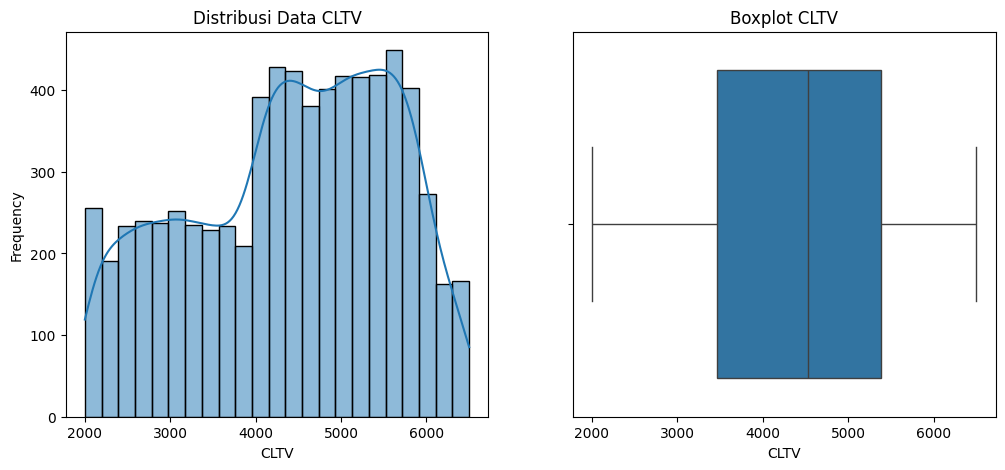

Analisis CLTV
count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: cltv, dtype: float64
Lower Bound: 601.75
Upper Bound: 8247.75
Jumlah Outlier: 0


In [ ]:
# Mengecek Distribusi CLTV
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df['cltv'], kde=True)
plt.title('Distribusi Data CLTV')
plt.xlabel('CLTV')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df['cltv'])
plt.title('Boxplot CLTV')
plt.xlabel('CLTV')

plt.show()

# Menghitung batas outlier menggunakan metode IQR
Q1 = df['cltv'].quantile(0.25)
Q3 = df['cltv'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengidentifikasi outlier
outliers = df[
    (df['cltv'] < lower_bound) |
    (df['cltv'] > upper_bound)
]

print('Analisis CLTV')
print(df['cltv'].describe())
print(f'Lower Bound: {lower_bound:.2f}')
print(f'Upper Bound: {upper_bound:.2f}')
print(f'Jumlah Outlier: {len(outliers)}')

In [ ]:
# Menghitung Quartil berdasarkan CLTV
clv_q1 = df["cltv"].quantile(0.25)
clv_q2 = df["cltv"].quantile(0.50)
clv_q3 = df["cltv"].quantile(0.75)

# Segmentasi berdasarkan Quartil
def clv_tier(x):
    if x <= clv_q1:
        return "Low"
    elif x <= clv_q2:
        return "Medium-Low"
    elif x <= clv_q3:
        return "Medium-High"
    else:
        return "High"

df["CLV Tier"] = df["cltv"].apply(clv_tier)

In [ ]:
# Total pelanggan per segment
segment_customer = (
    df.groupby('CLV Tier')['customer_id']
      .count()
      .reset_index()
      .sort_values(by='customer_id')
)

segment_customer

,CLV Tier,customer_id
3,Medium-Low,1759
2,Medium-High,1760
0,High,1761
1,Low,1763


## **4. Exploratory Data Analysis (EDA)**

### **4.1 Customer Profile**

### **4.1.1 Customer Status**

In [ ]:
# Menghitung jumlah customer unik
total_customer = df["customer_id"].nunique()

print("Total Customer:", total_customer)

# Menghitung jumlah customer berdasarkan customer status
customer_status = (
    df["customer_status"]
    .value_counts()
    .reset_index()
)

customer_status.columns = ["customer_status", "customer_count"]

customer_status

Total Customer: 7043


,customer_status,customer_count
0,Stayed,4720
1,Churned,1869
2,Joined,454


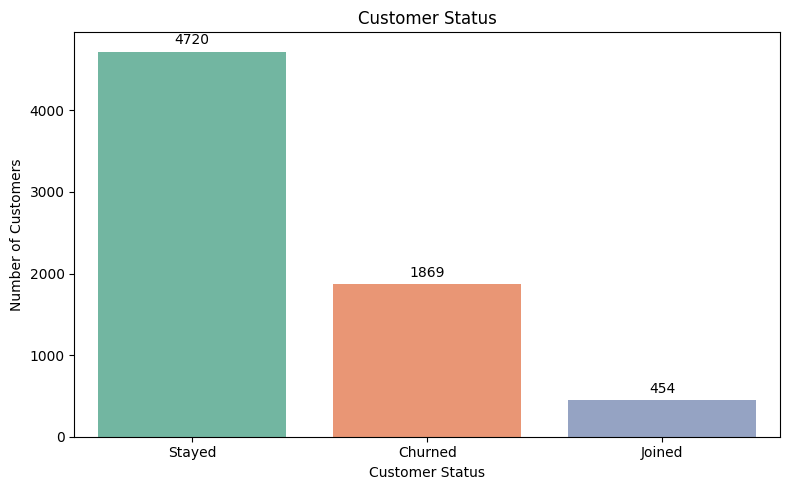

In [ ]:
# Visualisai
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=customer_status,
    x="customer_status",
    y="customer_count",
    hue="customer_status",
    palette="Set2",
    legend=False
)

plt.title("Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### **4.1.2 Gender**

In [ ]:
# Menghitung jumlah customer berdasarkan gender
gender = (
    df["gender"]
    .value_counts()
    .reset_index()
)

gender.columns = ["gender", "customer_count"]

gender

,gender,customer_count
0,Male,3555
1,Female,3488


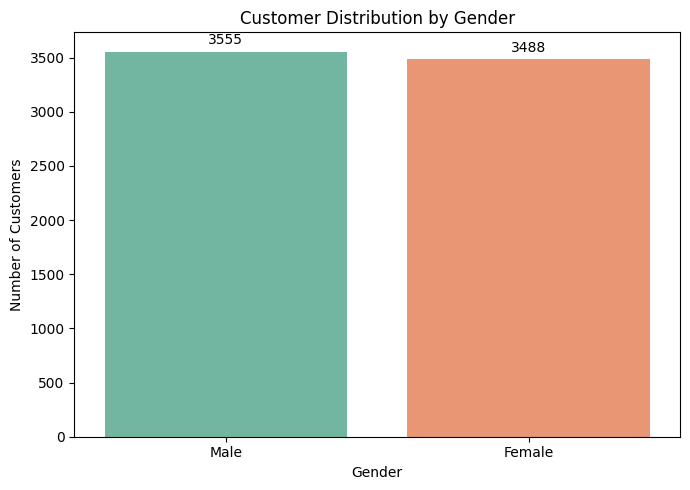

In [ ]:
# Visualisasi
plt.figure(figsize=(7,5))

# Bar Chart
ax = sns.barplot(
    data=gender,
    x="gender",
    y="customer_count",
    hue="gender",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### **4.1.3 Age**

In [ ]:
# Menghitung jumlah customer berdasarkan kelompok umur
age_group = (
    df["Age Group"]
    .value_counts()
    .reset_index()
)

age_group.columns = ["Age Group", "customer_count"]

age_group

,Age Group,customer_count
0,60+,1782
1,18-29,1401
2,40-49,1342
3,30-39,1266
4,50-59,1252


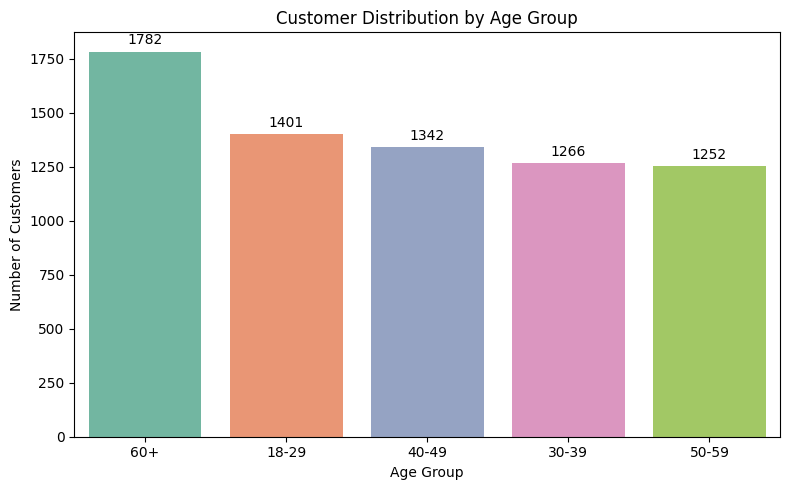

In [ ]:
# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=age_group,
    x="Age Group",
    y="customer_count",
    hue="Age Group",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### **4.1.4 Partner**

In [ ]:
# Menghitung jumlah customer berdasarkan status partner
partner = (
    df["partner"]
    .value_counts()
    .reset_index()
)

partner.columns = ["partner", "customer_count"]

partner

,partner,customer_count
0,No,3641
1,Yes,3402


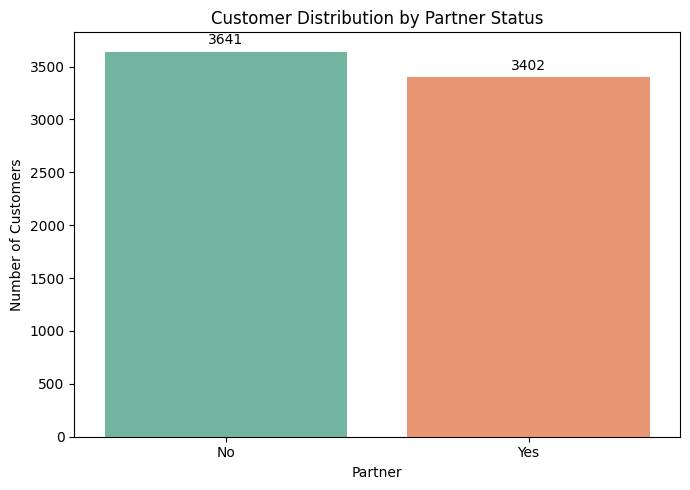

In [ ]:
# Visualisasi
plt.figure(figsize=(7,5))

# Bar Chart
ax = sns.barplot(
    data=partner,
    x="partner",
    y="customer_count",
    hue="partner",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### **4.1.5 Dependents**

In [ ]:
# Menghitung jumlah customer berdasarkan status dependents
dependents = (
    df["dependents"]
    .value_counts()
    .reset_index()
)

dependents.columns = ["dependents", "customer_count"]

dependents

,dependents,customer_count
0,No,5416
1,Yes,1627


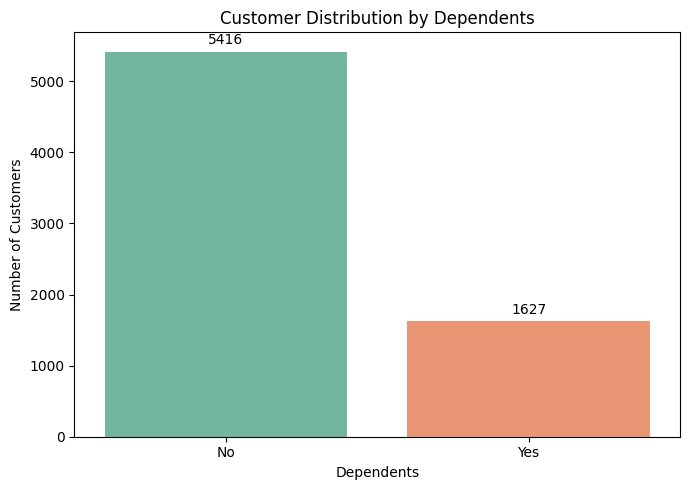

In [ ]:
# Visualisasi
plt.figure(figsize=(7,5))

# Bar Chart
ax = sns.barplot(
    data=dependents,
    x="dependents",
    y="customer_count",
    hue="dependents",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# # Menghitung jumlah customer berdasarkan jumlah dependents
number_dependents = (
    df["number_of_dependents"]
    .value_counts()
    .sort_index()
    .reset_index()
)

number_dependents.columns = ["number_of_dependents", "customer_count"]

number_dependents

,number_of_dependents,customer_count
0,0,5416
1,1,553
2,2,531
3,3,517
4,4,9
5,5,10
6,6,3
7,7,2
8,8,1
9,9,1


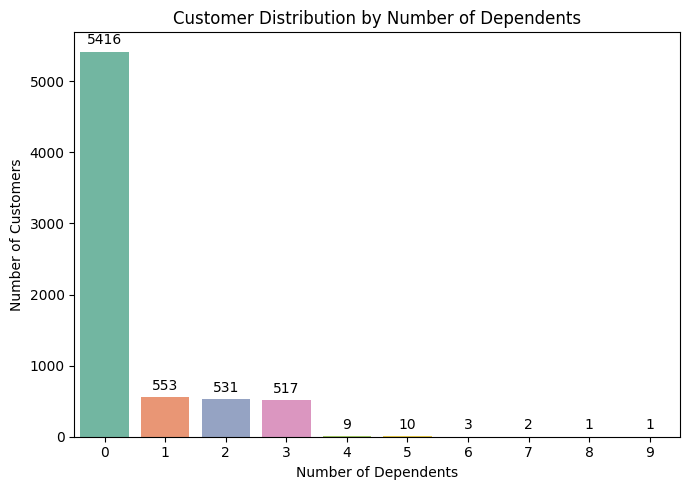

In [ ]:
# Visualisasi
plt.figure(figsize=(7,5))

# Bar Chart
ax = sns.barplot(
    data=number_dependents,
    x="number_of_dependents",
    y="customer_count",
    hue="number_of_dependents",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Number of Dependents")
plt.xlabel("Number of Dependents")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

4.2 Customer Value / CLV

### **4.2.1 Distribusi Customer Value**

In [ ]:
customer_value = df[
    [
        "cltv",
        "total_revenue",
        "monthly_ charges",
        "total_charges"
    ]
].describe()

customer_value

,cltv,total_revenue,monthly_ charges,total_charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,4400.295755,3034.379056,64.761692,2280.381264
std,1183.057152,2865.204542,30.090047,2266.220462
min,2003.000000,21.360000,18.250000,18.800000
25%,3469.000000,605.610000,35.500000,400.150000
50%,4527.000000,2108.640000,70.350000,1394.550000
75%,5380.500000,4801.145000,89.850000,3786.600000
max,6500.000000,11979.340000,118.750000,8684.800000


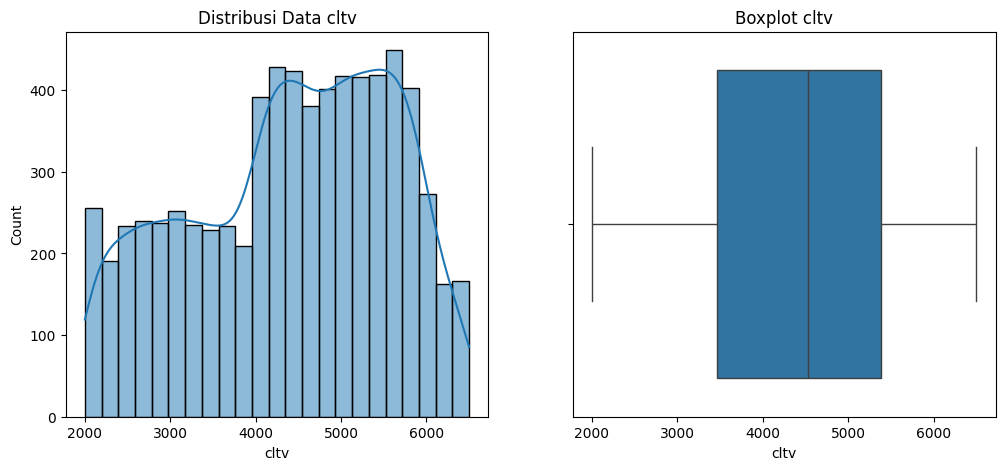

Analisis cltv
count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: cltv, dtype: float64
Lower Bound: 601.75
Upper Bound: 8247.75
Jumlah Outlier: 0



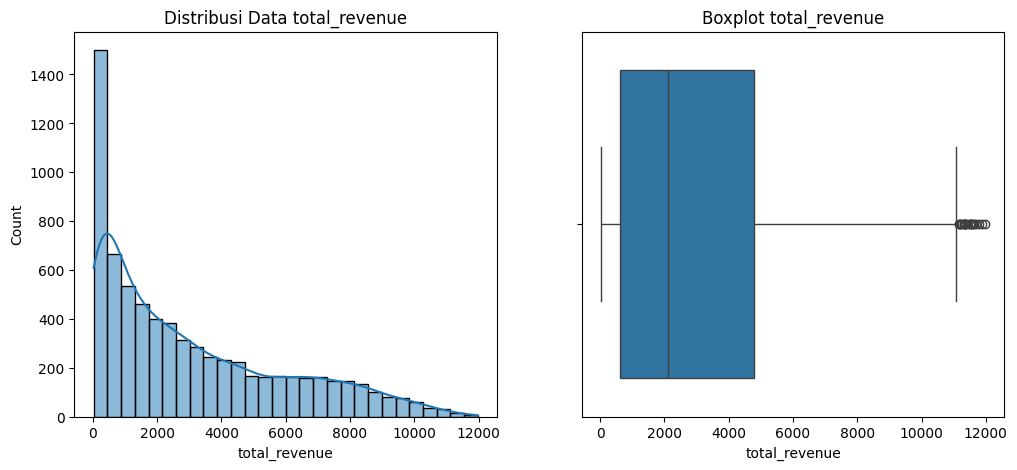

Analisis total_revenue
count     7043.000000
mean      3034.379056
std       2865.204542
min         21.360000
25%        605.610000
50%       2108.640000
75%       4801.145000
max      11979.340000
Name: total_revenue, dtype: float64
Lower Bound: -5687.69
Upper Bound: 11094.45
Jumlah Outlier: 21



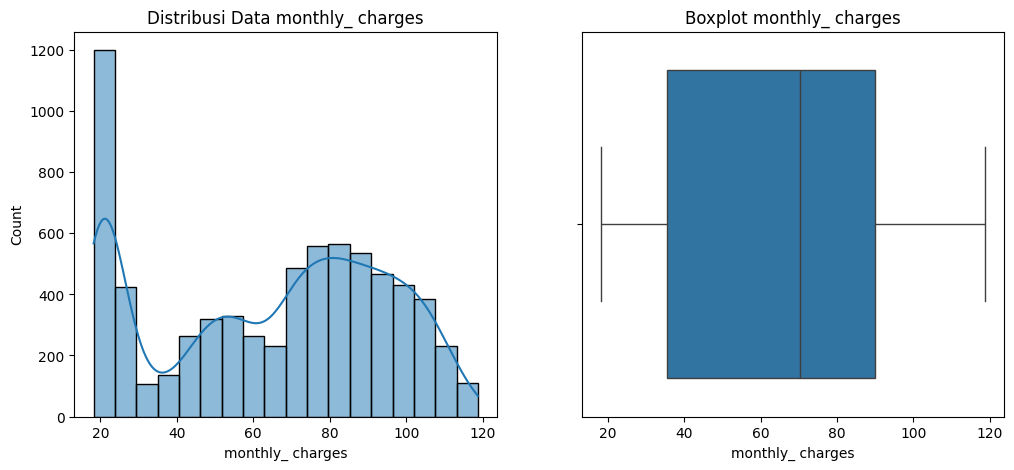

Analisis monthly_ charges
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_ charges, dtype: float64
Lower Bound: -46.02
Upper Bound: 171.38
Jumlah Outlier: 0



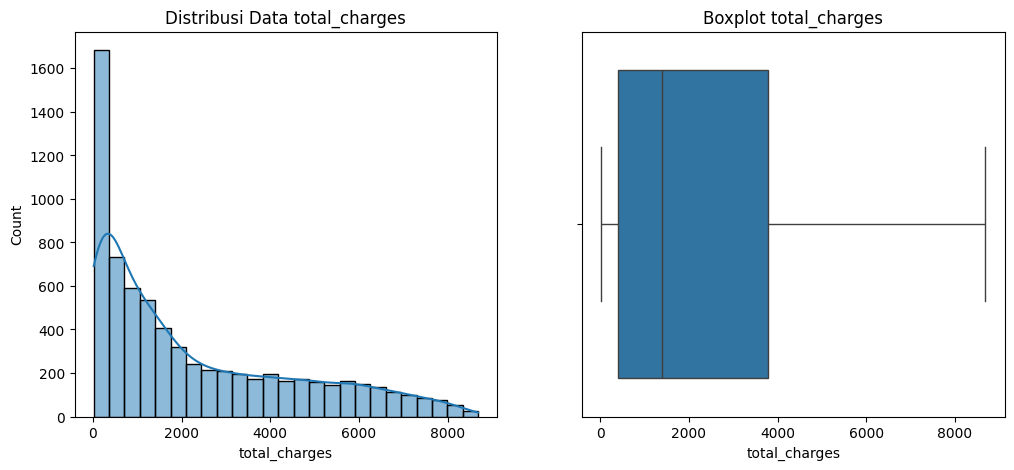

Analisis total_charges
count    7043.000000
mean     2280.381264
std      2266.220462
min        18.800000
25%       400.150000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: total_charges, dtype: float64
Lower Bound: -4679.52
Upper Bound: 8866.27
Jumlah Outlier: 0



In [ ]:
# Menentukan kolom customer value yang akan dianalisis
kolom_customer_value = [
    "cltv",
    "total_revenue",
    "monthly_ charges",
    "total_charges"
]

for kolom in kolom_customer_value:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi Data {kolom}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[kolom])
    plt.title(f'Boxplot {kolom}')

    plt.show()

    # Menghitung batas outlier menggunakan metode IQR
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mengidentifikasi outlier
    outliers = df[
        (df[kolom] < lower_bound) |
        (df[kolom] > upper_bound)
    ]

    # Menampilkan ringkasan statistik dan hasil outlier
    print(f'Analisis {kolom}')
    print(df[kolom].describe())
    print(f'Lower Bound: {lower_bound:.2f}')
    print(f'Upper Bound: {upper_bound:.2f}')
    print(f'Jumlah Outlier: {len(outliers)}')
    print()

### **4.2.2 Customer Distribution by CLV Tier**

In [ ]:
# Total pelanggan per segment
segment_customer = (
    df.groupby('CLV Tier')['customer_id']
      .count()
      .reset_index()
      .sort_values(by='customer_id')
)

segment_customer

,CLV Tier,customer_id
3,Medium-Low,1759
2,Medium-High,1760
0,High,1761
1,Low,1763


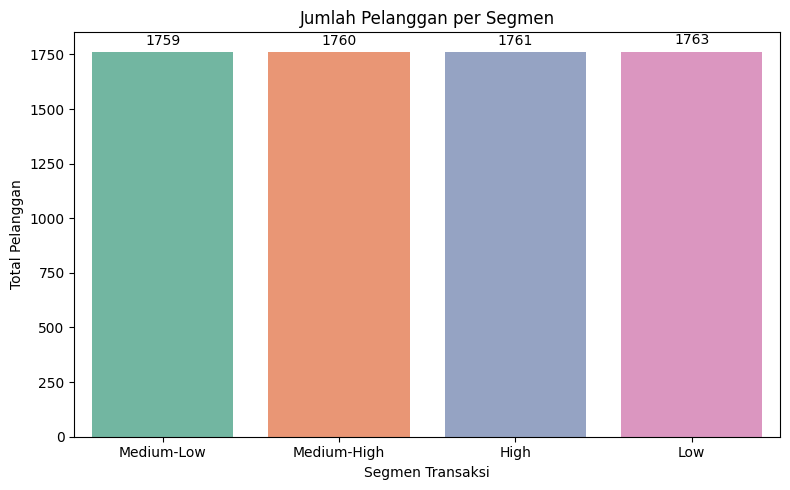

In [ ]:
# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
     data=segment_customer,
     x='CLV Tier',
     y='customer_id',
     hue='CLV Tier',
     palette='Set2',
     legend=False
)

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Jumlah Pelanggan per Segmen')
plt.xlabel('Segmen Transaksi')
plt.ylabel('Total Pelanggan')
plt.tight_layout()
plt.show()

In [ ]:
# Menghitung karakteristik customer berdasarkan CLV Tier
clv_summary = (
    df.groupby("CLV Tier", observed=True)
      .agg(
          customer_count=("customer_id", "nunique"),
          avg_cltv=("cltv", "mean"),
          avg_revenue=("total_revenue", "mean"),
          avg_monthly_charges=("monthly_ charges", "mean"),
          avg_total_charges=("total_charges", "mean")
      )
      .reset_index()
)

clv_summary

,CLV Tier,customer_count,avg_cltv,avg_revenue,avg_monthly_charges,avg_total_charges
0,High,1761,5819.813742,4112.877888,67.956246,3111.840432
1,Low,1763,2743.633012,1586.027623,60.630800,1177.444526
2,Medium-High,1760,4959.761364,3559.540608,66.307187,2681.153347
3,Medium-Low,1759,4079.810119,2880.838863,64.157419,2152.421632


## **4.3 Churn Overview**

In [ ]:
# Menghitung jumlah customer berdasarkan churn label
churn_overview = (
    df["churn_label"]
    .value_counts()
    .reset_index()
)

churn_overview.columns = [
    "churn_label",
    "customer_count"
]

churn_overview

,churn_label,customer_count
0,No,5174
1,Yes,1869


In [ ]:
# Menghitung jumlah customer yang churn
total_churn = (
    df["churn_label"]
    .eq("Yes")
    .sum()
)

# Menghitung total customer
total_customer = df["customer_id"].nunique()

# Menghitung persentase churn
churn_rate = (
    total_churn / total_customer
) * 100


print(f"Total Customer : {total_customer}")
print(f"Total Churn    : {total_churn}")
print(f"Churn Rate     : {churn_rate:.2f}%")

Total Customer : 7043
Total Churn    : 1869
Churn Rate     : 26.54%


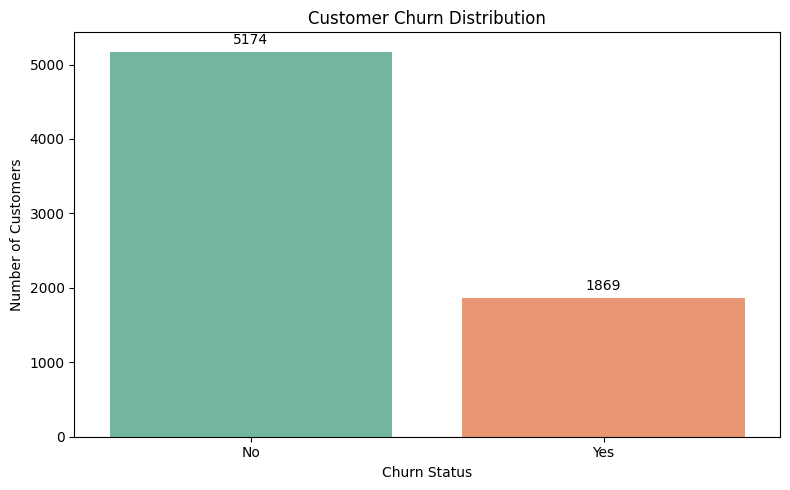

In [ ]:
# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=churn_overview,
    x="churn_label",
    y="customer_count",
    hue="churn_label",
    palette="Set2",
    legend=False
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [ ]:
# Menghitung jumlah customer berdasarkan customer status
customer_status = (
    df["customer_status"]
    .value_counts()
    .reset_index()
)

customer_status.columns = [
    "customer_status",
    "customer_count"
]

customer_status

,customer_status,customer_count
0,Stayed,4720
1,Churned,1869
2,Joined,454


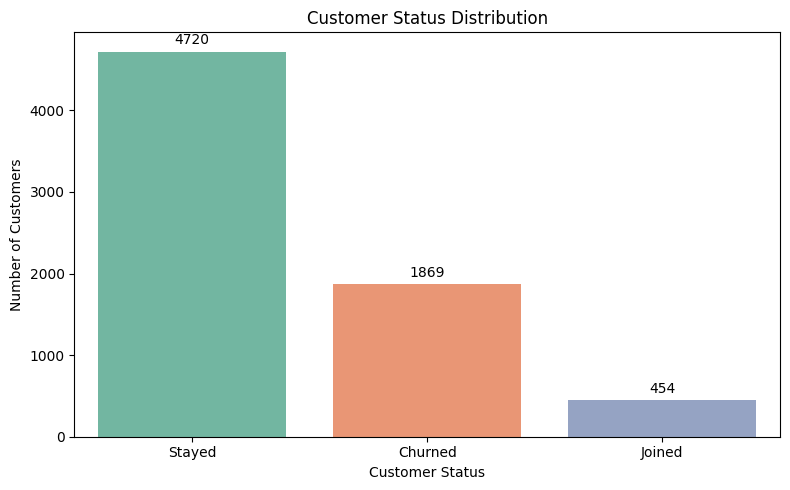

In [ ]:
# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=customer_status,
    x="customer_status",
    y="customer_count",
    hue="customer_status",
    palette="Set2",
    legend=False
)

plt.title("Customer Status Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()
plt.show()

## **4.4 Churn by Customer Profile**

### **4.4.1 Gender**

In [ ]:
# Mengecek jumlah customer churn per gender
gender_churn_label = pd.crosstab(
                df["gender"],
                df["churn_label"]
)

gender_churn_label

churn_label,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [ ]:
# Churn Rate (%) per age group
gender_churn = (
    df.groupby("gender")["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

gender_churn

,churn_label
gender,
Female,26.920872
Male,26.160338


/tmp/ipykernel_3172/1688323169.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


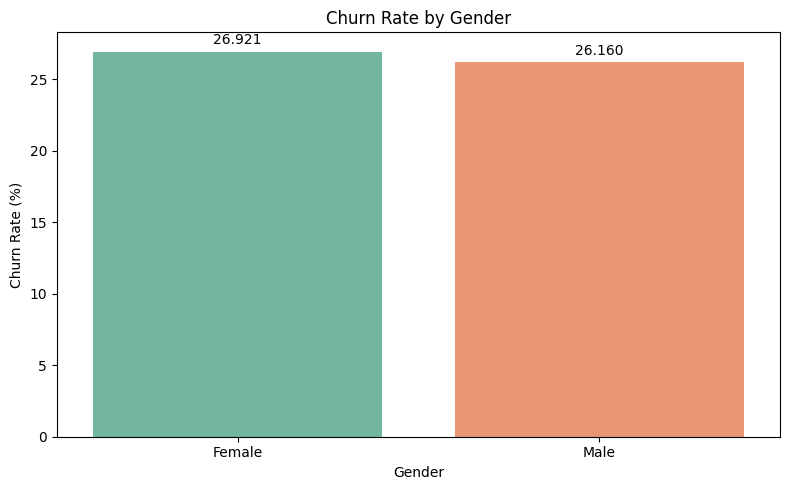

In [ ]:
gender_churn_df = gender_churn.reset_index(name='Churn Rate')

# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=gender_churn_df,
    x="gender",
    y="Churn Rate",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

### **4.4.2 Age Group**

In [ ]:
# Mengecek jumlah customer churn per gender
age_group_label = pd.crosstab(
                df["Age Group"],
                df["churn_label"]
)

age_group_label

churn_label,No,Yes
Age Group,,
18-29,1097,304
30-39,957,309
40-49,1024,318
50-59,945,307
60+,1151,631


In [ ]:
# Churn Rate (%) per age group
age_group_churn = (
    df.groupby("Age Group", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

age_group_churn

,churn_label
Age Group,
60+,35.409652
50-59,24.520767
30-39,24.407583
40-49,23.695976
18-29,21.698787


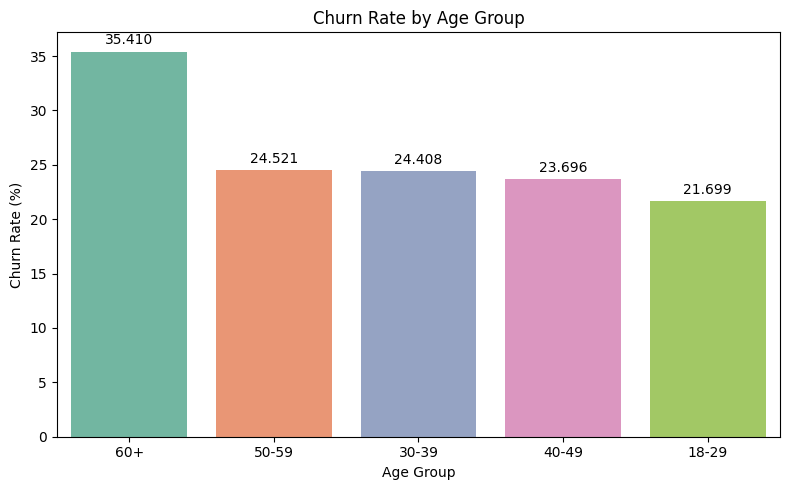

In [ ]:
age_group_churn_df = age_group_churn.reset_index(name='Churn Rate')

# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=age_group_churn_df,
    x="Age Group",
    y="Churn Rate",
    hue="Age Group", # Added to align with best practices and suppress FutureWarning
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

### **4.4.3 Partner**

In [ ]:
# Mengecek jumlah customer churn per gender
partner_churn_label = pd.crosstab(
                df["partner"],
                df["churn_label"]
)

partner_churn_label

churn_label,No,Yes
partner,,
No,2441,1200
Yes,2733,669


In [ ]:
# Churn Rate (%) per partner
partner_churn = (
    df.groupby("partner", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

partner_churn

,churn_label
partner,
No,32.957979
Yes,19.664903


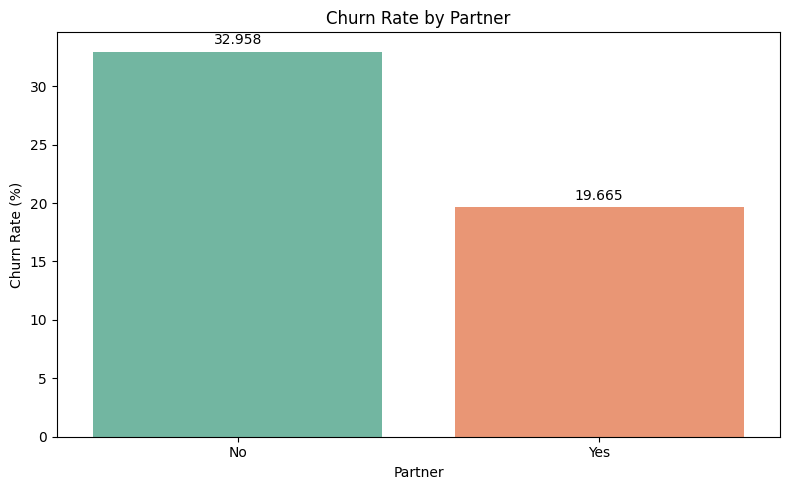

In [ ]:
partner_churn_df = partner_churn.reset_index(name='Churn Rate')

# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=partner_churn_df,
    x="partner",
    y="Churn Rate",
    hue="partner",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Partner")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

### **4.4.4 Dependents**

In [ ]:
# Mengecek jumlah customer churn per gender
dependents_label = pd.crosstab(
                df["dependents"],
                df["churn_label"]
)

dependents_label

churn_label,No,Yes
dependents,,
No,3653,1763
Yes,1521,106


In [ ]:
# Churn Rate (%) per partner
dependents_churn = (
    df.groupby("dependents", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

dependents_churn

,churn_label
dependents,
No,32.551699
Yes,6.515058


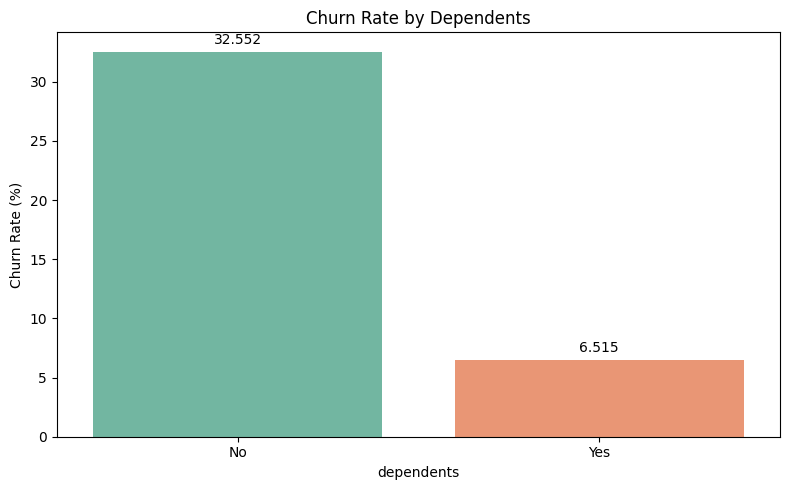

In [ ]:
dependents_churn_df = dependents_churn.reset_index(name='Churn Rate')

# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=dependents_churn_df,
    x="dependents",
    y="Churn Rate",
    hue="dependents",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Dependents")
plt.xlabel("dependents")
plt.ylabel("Churn Rate (%)")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

### **4.4.5 CLV Tier**

In [ ]:
# Mengecek Jumlah customer churn per segment
segment_churn = pd.crosstab(
                df["CLV Tier"],
                df["churn_label"]
)

segment_churn

churn_label,No,Yes
CLV Tier,,
High,1396,365
Low,1156,607
Medium-High,1335,425
Medium-Low,1287,472


In [ ]:
# Churn Rate (%) per CLV Tier
clv_tier_churn = (
    df.groupby("CLV Tier", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

clv_tier_churn

,churn_label
CLV Tier,
Low,34.429949
Medium-Low,26.833428
Medium-High,24.147727
High,20.726860


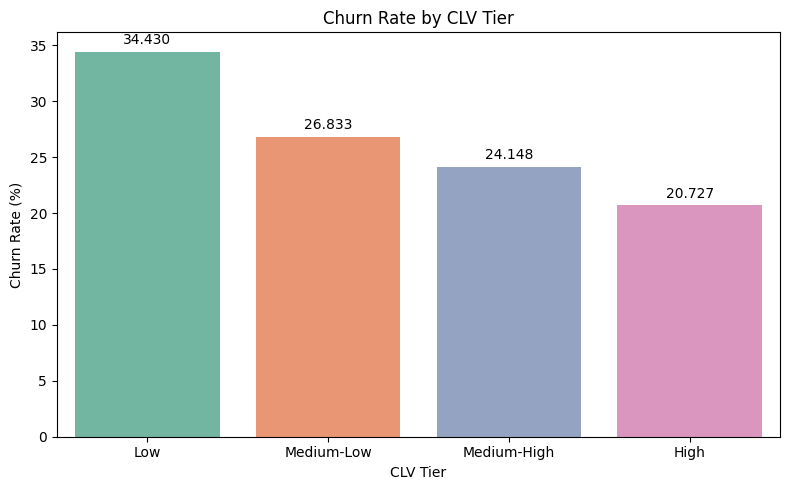

In [ ]:
clv_tier_churn_df = clv_tier_churn.reset_index(name='Churn Rate')

# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=clv_tier_churn_df,
    x="CLV Tier",
    y="Churn Rate",
    hue="CLV Tier",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by CLV Tier")
plt.xlabel("CLV Tier")
plt.ylabel("Churn Rate (%)")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

## **4.5 Churn by Service**

### **4.5.1 Contract**

In [ ]:
# Mengecek Jumlah customer churn by contract
contract_churn_label = pd.crosstab(
                df["contract"],
                df["churn_label"]
)

contract_churn_label

churn_label,No,Yes
contract,,
Month-to-Month,1955,1655
One Year,1384,166
Two Year,1835,48


In [ ]:
# Churn Rate (%) by Contract
contract_churn = (
    df.groupby("contract", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

clv_tier_churn

,churn_label
CLV Tier,
Low,34.429949
Medium-Low,26.833428
Medium-High,24.147727
High,20.726860


### **4.5.2 Internet Service**

In [ ]:
# Mengecek Jumlah Jumlah Customer Churn by Internet Service
internet_service_churn_label = pd.crosstab(
                df["internet_service"],
                df["churn_label"]
)

internet_service_churn_label

churn_label,No,Yes
internet_service,,
No,1413,113
Yes,3761,1756


In [ ]:
# Churn Rate (%) by internet service
internet_service_churn = (
    df.groupby("internet_service", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

internet_service_churn

,churn_label
internet_service,
Yes,31.828893
No,7.404980


### **4.2.3 Phone Service**

In [ ]:
# Mengecek Jumlah Customer Churn by Phone Service
phone_service_churn_label = pd.crosstab(
                df["phone_service"],
                df["churn_label"]
)

phone_service_churn_label

churn_label,No,Yes
phone_service,,
No,512,170
Yes,4662,1699


In [ ]:
# Churn Rate (%) by Phone Service
internet_service_churn = (
    df.groupby("phone_service", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

internet_service_churn

,churn_label
phone_service,
Yes,26.709637
No,24.926686


### **4.2.4 Internet Type**

In [ ]:
# Mengecek Jumlah Customer Churn by Internet Type
internet_type_churn_label = pd.crosstab(
                df["internet_type"],
                df["churn_label"]
)

internet_type_churn_label

churn_label,No,Yes
internet_type,,
Cable,617,213
DSL,1345,307
Fiber Optic,1799,1236


In [ ]:
# Churn Rate (%) by Internet Type
internet_service_churn = (
    df.groupby("internet_type", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

internet_service_churn

,churn_label
internet_type,
Fiber Optic,40.724876
Cable,25.662651
DSL,18.583535


## **4.6 Churn by Payment Methods**

In [ ]:
# Mengecek Jumlah Customer Churn by Payment Methods
payment_methods_churn_label = pd.crosstab(
                df["payment_method"],
                df["churn_label"]
)

payment_methods_churn_label

churn_label,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [ ]:
# Churn Rate (%) by Payment Methods
payment_methods_churn = (
    df.groupby("payment_method", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

payment_methods_churn

,churn_label
payment_method,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


## **4.8 Geographical Analysis**

### **4.8.1 City**

In [ ]:
# Mengecek Jumlah Customer Churn by City
city_churn_label = (
    pd.crosstab(df["city"], df["churn_label"])
      .sort_values("Yes", ascending=False)
      .head(5)
)

city_churn_label

churn_label,No,Yes
city,,
San Diego,100,185
Los Angeles,215,78
San Francisco,73,31
San Jose,83,29
Fallbrook,17,26


<Figure size 800x500 with 0 Axes>

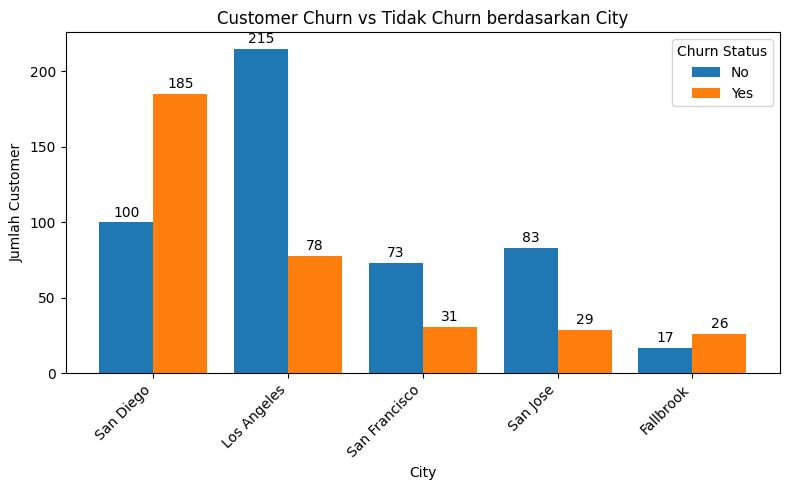

In [ ]:
# Visualiasasi
plt.figure(figsize=(8, 5))

# Bar Chart
ax = city_churn_label.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.8
)

plt.title("Customer Churn vs Tidak Churn berdasarkan City")
plt.xlabel("City")
plt.ylabel("Jumlah Customer")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn Status")

# Label Angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=2
    )

plt.tight_layout()
plt.show()

In [ ]:
# Churn Rate (%) by Phone Service
city_churn = (
    df.groupby("city", observed=True)["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)


In [ ]:
# Churn Rate (%) by City
top_cities = city_churn_label.index

city_churn = (
    df[df["city"].isin(top_cities)]
    .groupby("city")["churn_label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

city_churn

,churn_label
city,
San Diego,64.912281
Fallbrook,60.465116
San Francisco,29.807692
Los Angeles,26.621160
San Jose,25.892857


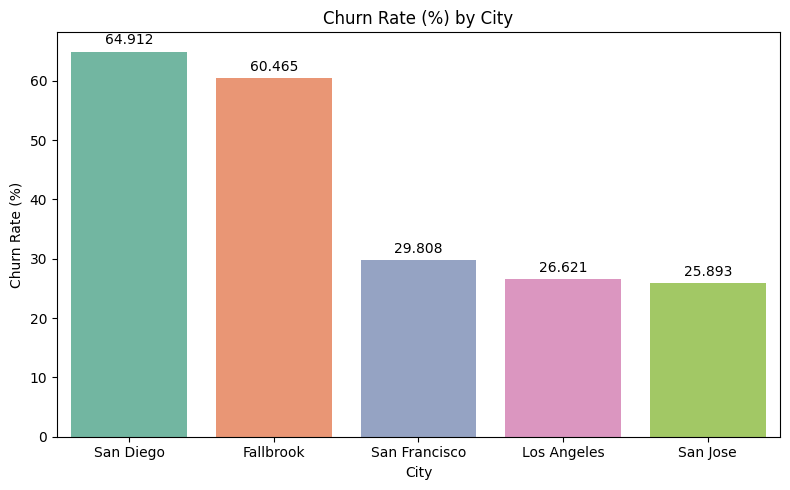

In [ ]:
city_churn_df = city_churn.reset_index(name='Churn Rate')

# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=city_churn_df,
    x="city",
    y="Churn Rate",
    hue="city",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate (%) by City")
plt.xlabel("City")
plt.ylabel("Churn Rate (%)")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

## **4.9 Churn Reason Analysis**

In [ ]:
churn_category_label= (
    df[df["churn_label"] == "Yes"]["churn_category"]
    .value_counts()
)

churn_category_label

,count
churn_category,
Competitor,841
Attitude,314
Dissatisfaction,303
Price,211
Other,200


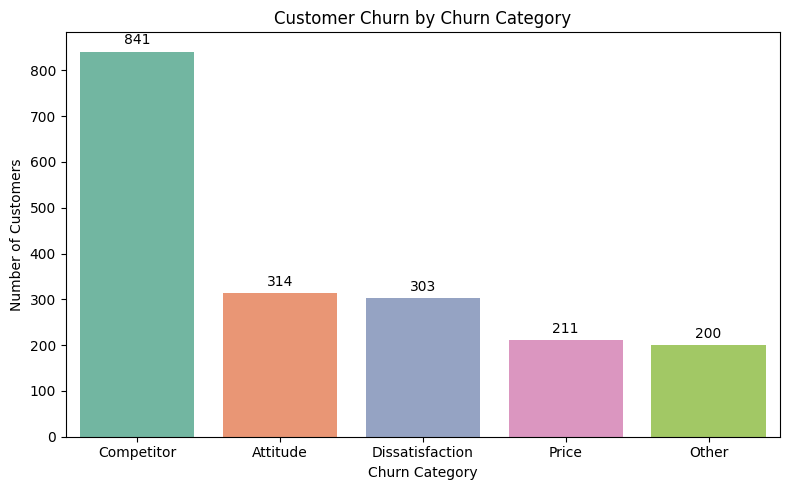

In [ ]:
churn_category_df = churn_category_label.reset_index()

# Visualisai
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=churn_category_df,
    x="churn_category",
    y="count",
    hue="churn_category",
    palette="Set2",
    legend=False
)

plt.title("Customer Churn by Churn Category")
plt.xlabel("Churn Category")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()
plt.show()

### **4.9.2 Reason**

In [ ]:
churn_reason_label= (
    df[df["churn_label"] == "Yes"]["churn_reason"]
    .value_counts()
    .head(5)
)

churn_reason_label

,count
churn_reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117


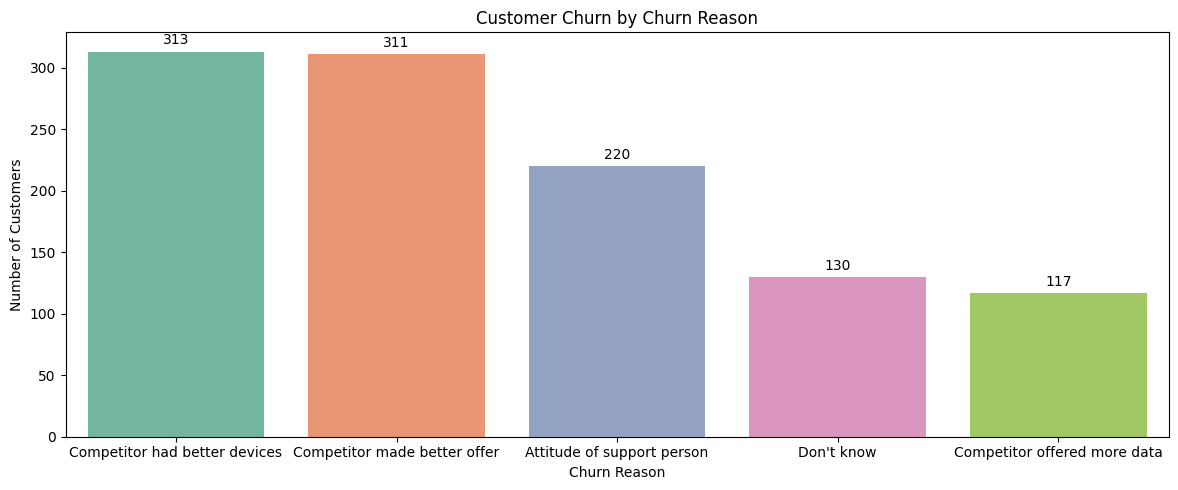

In [ ]:
churn_reason_df = churn_reason_label.reset_index()

# Visualisai
plt.figure(figsize=(12,5))

# Bar Chart
ax = sns.barplot(
    data=churn_reason_df,
    x="churn_reason",
    y="count",
    hue="churn_reason",
    palette="Set2",
    legend=False
)

plt.title("Customer Churn by Churn Reason")
plt.xlabel("Churn Reason")
plt.ylabel("Number of Customers")

# Label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()
plt.show()